# 2. Visualise PyNNLF Output: ASHD vs AEDP 148 Households

Plots the 1-day comparison figures.

## 1. Setup And Paths

In [1]:
from pathlib import Path
import sys

def find_publication_project(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "specs").exists() and (candidate / "data").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find publication/journal_article_1 from the current working directory.")

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "pynnlf").exists():
            return candidate
    raise FileNotFoundError("Could not find the PyNNLF repo root.")

PROJECT_DIR = find_publication_project()
REPO_ROOT = find_repo_root(PROJECT_DIR)
print(f"Publication project: {PROJECT_DIR}")
print(f"Repository root: {REPO_ROOT}")
import pandas as pd
import matplotlib.pyplot as plt
RESULTS_DIR = PROJECT_DIR / "results" / "01_ashd_aedp_148hh_comparison"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ORDER = ['m1_naive_hp1', 'm2_snaive_hp2', 'm3_ets_hp1', 'm4_arima_hp1', 'm6_lr_hp1', 'm7_ann_hp1', 'm8_dnn_hp1', 'm9_rt_hp3', 'm10_rf_hp1', 'm13_lstm_hp2', 'm16_prophet_hp1', 'm17_xgb_hp1']
DATASET_LABELS = {"ASHD_148hh_weather": "ASHD 148 households", "AEDP_148hh_weather": "AEDP 148 households"}
COLORS = {"ASHD_148hh_weather": "#2F4D67", "AEDP_148hh_weather": "#EB932C"}
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.25})
def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

Publication project: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1
Repository root: C:\Users\z5404477\Documents\PyNNLF


## 2. Load Processed Tables

In [2]:
required_files = {
    "comparison_nrmse": RESULTS_DIR / "ashd_aedp_148hh_fh8_nrmse_comparison.csv",
    "comparison_stddev": RESULTS_DIR / "ashd_aedp_148hh_fh8_nrmse_stddev_comparison.csv",
}
missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing processed result files. Run notebook 1 first. " + str(missing))
comparison_nrmse = pd.read_csv(required_files["comparison_nrmse"], index_col=0).reindex(MODEL_ORDER)
comparison_stddev = pd.read_csv(required_files["comparison_stddev"], index_col=0).reindex(MODEL_ORDER)
display(comparison_nrmse.round(3))

,ASHD_148hh_weather,AEDP_148hh_weather
model_hp,,
m1_naive_hp1,9.091,24.298
m2_snaive_hp2,10.953,30.027
m3_ets_hp1,9.142,24.184
m4_arima_hp1,16.179,37.021
m6_lr_hp1,7.763,20.951
m7_ann_hp1,8.150,20.380
m8_dnn_hp1,7.690,20.408
m9_rt_hp3,10.122,26.321
m10_rf_hp1,8.490,21.893


## 3. nRMSE Comparison Figure

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\fig01_ashd_aedp_fh8_nrmse_comparison.png


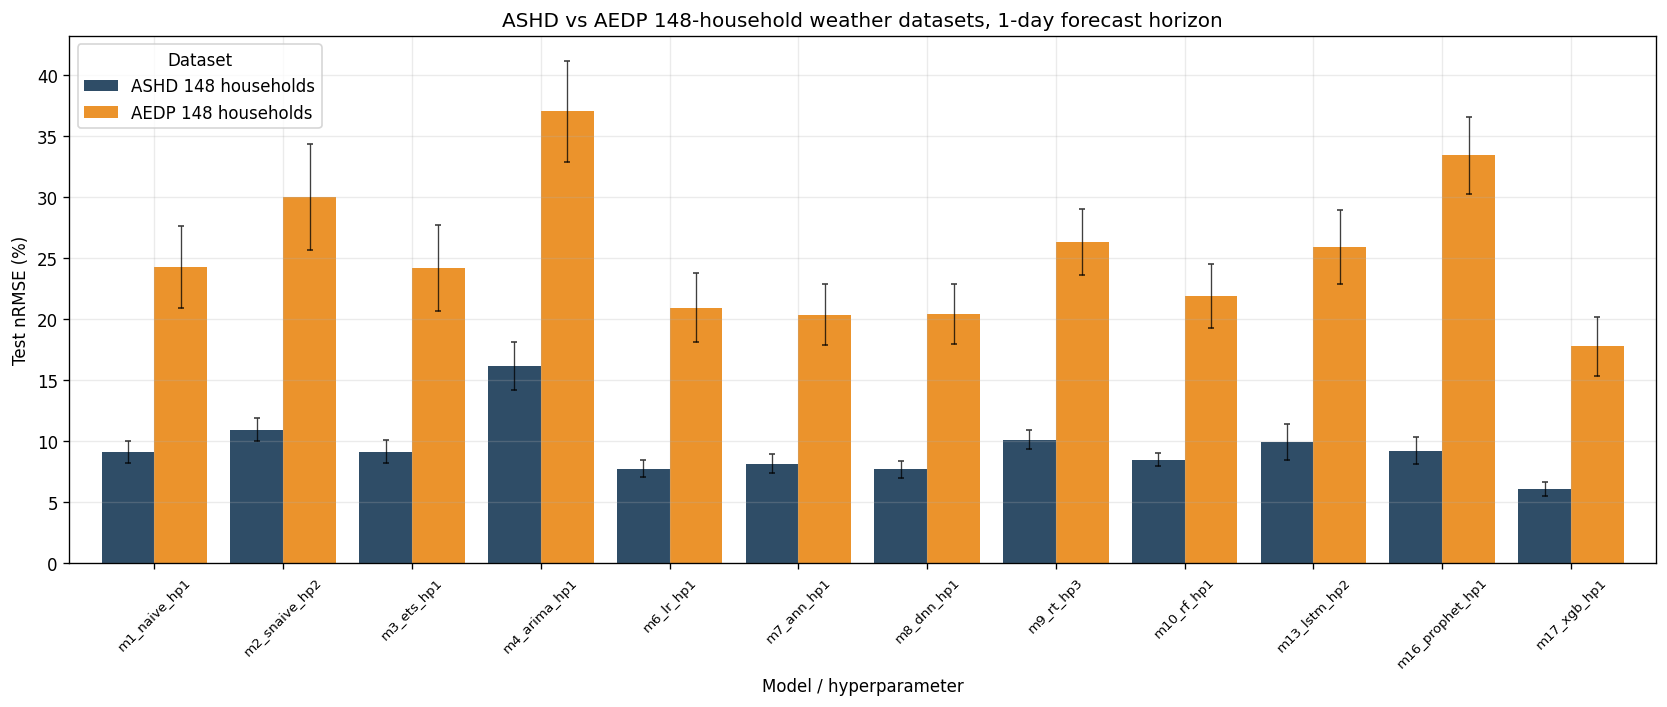

In [3]:
plot_nrmse = comparison_nrmse.rename(columns=DATASET_LABELS)
plot_stddev = comparison_stddev.rename(columns=DATASET_LABELS)
fig, ax = plt.subplots(figsize=(14, 6))
plot_nrmse.plot(kind="bar", yerr=plot_stddev, ax=ax, width=0.82, capsize=2, color=[COLORS[column] for column in comparison_nrmse.columns], error_kw={"elinewidth": 0.8, "alpha": 0.75})
ax.set_ylabel("Test nRMSE (%)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("ASHD vs AEDP 148-household weather datasets, 1-day forecast horizon")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Dataset")
fig.tight_layout()
save_figure(fig, "fig01_ashd_aedp_fh8_nrmse_comparison.png")
plt.show()

## 4. Difference Figure

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\fig02_ashd_minus_aedp_fh8_nrmse_difference.png


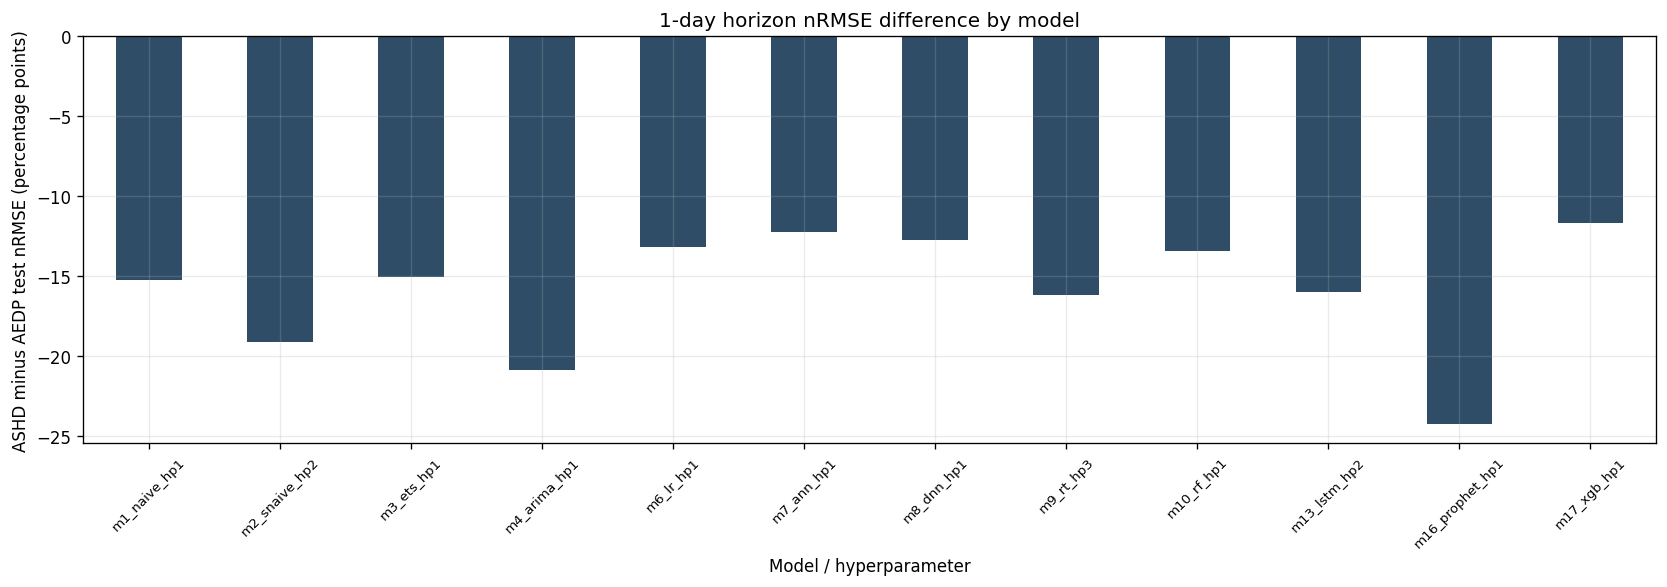

In [4]:
difference = comparison_nrmse["ASHD_148hh_weather"] - comparison_nrmse["AEDP_148hh_weather"]
fig, ax = plt.subplots(figsize=(14, 5))
difference.plot(kind="bar", ax=ax, color=["#2F4D67" if value <= 0 else "#EB932C" for value in difference])
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("ASHD minus AEDP test nRMSE (percentage points)")
ax.set_xlabel("Model / hyperparameter")
ax.set_title("1-day horizon nRMSE difference by model")
ax.tick_params(axis="x", rotation=45, labelsize=8)
fig.tight_layout()
save_figure(fig, "fig02_ashd_minus_aedp_fh8_nrmse_difference.png")
plt.show()

## 5. Figure Inventory

In [5]:
for path in sorted(FIGURES_DIR.glob("fig*.png")):
    print(path)

C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\fig01_ashd_aedp_fh8_nrmse_comparison.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\fig02_ashd_minus_aedp_fh8_nrmse_difference.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\fig04_ashd_aedp_fh8_nrmse_comparison.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\01_ashd_aedp_148hh_comparison\figures\fig05_ashd_minus_aedp_fh8_nrmse_difference.png
